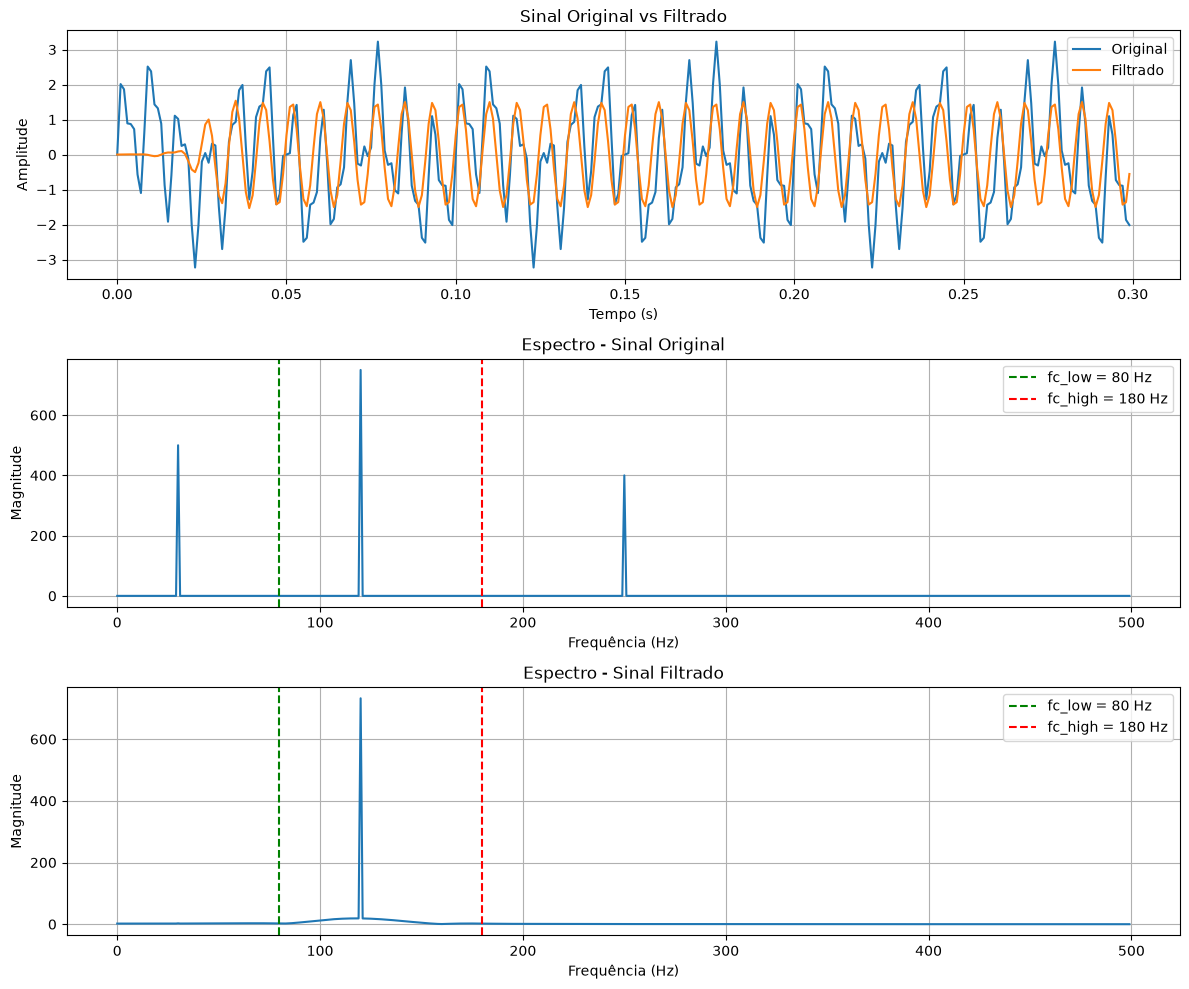

Análise das componentes espectrais:
Frequência 30 Hz: rejeitada (atenuada pelo filtro)
Frequência 120 Hz: selecionada (permanece no filtro)
Frequência 250 Hz: rejeitada (atenuada pelo filtro)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Parâmetros
fs = 1000
t = np.arange(0, 1, 1/fs)

# Sinal composto com três frequências
frequencias = [30, 120, 250]
amplitudes = [1.0, 1.5, 0.8]
sinal = np.zeros(len(t))
for f, A in zip(frequencias, amplitudes):
    sinal += A * np.sin(2*np.pi*f*t)

# Projeto do filtro passa-faixa
f_low = 80   # Frequência de corte inferior (Hz)
f_high = 180 # Frequência de corte superior (Hz)
ordem = 50

# FIR passa-faixa
b = signal.firwin(ordem, [f_low, f_high], fs=fs, window='hamming', pass_zero=False)

# Aplicar filtro
sinal_filtrado = signal.lfilter(b, [1.0], sinal)

# Análise espectral
N = len(sinal)
freq = fftfreq(N, 1/fs)
mag_original = np.abs(fft(sinal))
mag_filtrado = np.abs(fft(sinal_filtrado))

# Gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Sinal no tempo
axes[0].plot(t[:300], sinal[:300], label='Original')
axes[0].plot(t[:300], sinal_filtrado[:300], label='Filtrado')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Sinal Original vs Filtrado')
axes[0].legend()
axes[0].grid()

# Espectro original
axes[1].plot(freq[:N//2], mag_original[:N//2])
axes[1].axvline(f_low, color='g', linestyle='--', label=f'fc_low = {f_low} Hz')
axes[1].axvline(f_high, color='r', linestyle='--', label=f'fc_high = {f_high} Hz')
axes[1].set_xlabel('Frequência (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Espectro - Sinal Original')
axes[1].legend()
axes[1].grid()

# Espectro filtrado
axes[2].plot(freq[:N//2], mag_filtrado[:N//2])
axes[2].axvline(f_low, color='g', linestyle='--', label=f'fc_low = {f_low} Hz')
axes[2].axvline(f_high, color='r', linestyle='--', label=f'fc_high = {f_high} Hz')
axes[2].set_xlabel('Frequência (Hz)')
axes[2].set_ylabel('Magnitude')
axes[2].set_title('Espectro - Sinal Filtrado')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

# Verificação das frequências selecionadas
print("Análise das componentes espectrais:")
for f in frequencias:
    idx = np.argmin(np.abs(freq[:N//2] - f))
    if f_low <= f <= f_high:
        print(f"Frequência {f} Hz: selecionada (permanece no filtro)")
    else:
        print(f"Frequência {f} Hz: rejeitada (atenuada pelo filtro)")

# Discussão dos Resultados
O filtro passa-faixa seleciona efetivamente a componente de 120 Hz, atenuando significativamente as componentes de 30 Hz e 250 Hz. A resposta espectral mostra que o filtro atua como uma "janela de seleção" no domínio da frequência, permitindo a passagem apenas das componentes dentro da faixa especificada. Esta técnica é fundamental em aplicações de extração de sinais de interesse em meio a interferências.